# Why does the naive (persistence) predictor win?

In notebooks 8–11, the **naive** method—predict next value = last observed value—often has the **lowest** MAE/RMSE compared to GCN+LSTM, LSTM-only, HAC-LSTM, etc. This notebook explores **why** that happens and whether it's a coincidence.

- **Naive (persistence):** \(\hat{y}_t = y_{t-1}\).
- We compare to simple baselines (global mean, per-channel mean) and inspect **autocorrelation** and **step size** to see if the series are highly persistent.

## Load data and split (same as time_series_8/10)

Use the same transformed data and 60/10/30 train/val/test split so results are comparable.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

_root = Path.cwd().resolve()
if _root.name == "time_series":
    _root = _root.parent
DATA_PATH = _root / "data" / "transformed" / "transformed_data.parquet"
if not DATA_PATH.exists():
    DATA_PATH = DATA_PATH.with_suffix(".csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Transform data not found at {DATA_PATH}. Run task transform first.")

df = pd.read_parquet(DATA_PATH) if DATA_PATH.suffix == ".parquet" else pd.read_csv(DATA_PATH)
df = df.sort_values(["date", "hour"]).reset_index(drop=True)
df["datetime"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="h")

freq_bands = sorted([c for c in df.columns if c not in ("date", "hour", "datetime")])
N = len(freq_bands)
Z = df[freq_bands].values.astype(np.float64)
Z = np.nan_to_num(Z, nan=0.0, posinf=0.0, neginf=0.0)
T_total = Z.shape[0]

train_ratio, val_ratio, test_ratio = 0.6, 0.1, 0.3
n_train = int(T_total * train_ratio)
n_val = int(T_total * val_ratio)
n_test = T_total - n_train - n_val

Z_train = Z[:n_train]
Z_val = Z[n_train : n_train + n_val]
Z_test = Z[n_train + n_val :]

print(f"Shape: (T={T_total}, N={N}). Train: {n_train}, Val: {n_val}, Test: {n_test}")

Shape: (T=9192, N=70). Train: 5515, Val: 919, Test: 2758


## Optional: use low-pass filtered data (as in time_series_10)

If you use filtered data in ts10, uncomment below so we analyze the same series. Filtered data is **smoother**, so persistence tends to look even better.

In [2]:
USE_LOWPASS = True  # set False to use raw Z
if USE_LOWPASS:
    from scipy.signal import butter, filtfilt
    def lowpass_per_channel(Z_mat, cutoff=0.5, order=3):
        normal_cutoff = min(float(cutoff), 0.99)
        b, a = butter(order, normal_cutoff, btype="low", analog=False)
        out = np.zeros_like(Z_mat)
        for j in range(Z_mat.shape[1]):
            out[:, j] = filtfilt(b, a, Z_mat[:, j])
        return out
    Z_full = lowpass_per_channel(Z, cutoff=0.5, order=3)
    Z_train = Z_full[:n_train]
    Z_val = Z_full[n_train : n_train + n_val]
    Z_test = Z_full[n_train + n_val :]
    print("Using low-pass filtered data (cutoff=0.5).")
else:
    Z_full = Z.copy()
    print("Using raw data.")

Using low-pass filtered data (cutoff=0.5).


## Three baselines on test set

1. **Naive (persistence):** \(\hat{y}_t = y_{t-1}\) (last observed value).  
2. **Global mean:** \(\hat{y}_t = \bar{y}_{\text{train}}\) (same constant for all channels and steps).  
3. **Per-channel mean:** \(\hat{y}_{t,j} = \bar{y}_{\text{train},j}\) (channel \(j\)'s training mean).  

If naive wins by a large margin, the series are **persistent** (next ≈ last). If mean predictors are close, the series might be near-constant or low signal.

In [3]:
def mae_rmse_mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    mape = float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100)
    return mae, rmse, mape

# Naive: last value (use full history so test step t uses value at test_start + t - 1)
test_start = n_train + n_val
pred_naive = np.zeros_like(Z_test)
for t in range(n_test):
    pred_naive[t] = Z_full[test_start + t - 1] if t > 0 else Z_full[test_start - 1]

# Global mean (scalar broadcast to (n_test, N))
global_mean = np.mean(Z_train)
pred_global_mean = np.full_like(Z_test, global_mean)

# Per-channel mean (1, N) broadcast to (n_test, N)
channel_mean = np.mean(Z_train, axis=0)
pred_channel_mean = np.broadcast_to(channel_mean, Z_test.shape)

mae_n, rmse_n, mape_n = mae_rmse_mape(Z_test, pred_naive)
mae_g, rmse_g, mape_g = mae_rmse_mape(Z_test, pred_global_mean)
mae_c, rmse_c, mape_c = mae_rmse_mape(Z_test, pred_channel_mean)

print("Test set metrics (lower is better):")
print(f"  Naive (persistence):     MAE = {mae_n:.4f},  RMSE = {rmse_n:.4f},  MAPE = {mape_n:.2f}%")
print(f"  Global mean:            MAE = {mae_g:.4f},  RMSE = {rmse_g:.4f},  MAPE = {mape_g:.2f}%")
print(f"  Per-channel mean:       MAE = {mae_c:.4f},  RMSE = {rmse_c:.4f},  MAPE = {mape_c:.2f}%")
print()
print("Naive wins by large margin? → Series are highly persistent (next value ≈ last value).")

Test set metrics (lower is better):
  Naive (persistence):     MAE = 2.7672,  RMSE = 4.5277,  MAPE = 13.01%
  Global mean:            MAE = 14.0373,  RMSE = 21.1124,  MAPE = 110.39%
  Per-channel mean:       MAE = 13.1589,  RMSE = 19.7923,  MAPE = 98.11%

Naive wins by large margin? → Series are highly persistent (next value ≈ last value).


## Why persistence works: lag-1 autocorrelation

If \(\text{corr}(y_t, y_{t-1})\) is close to 1, then \(y_t \approx y_{t-1}\) in a mean-squared sense, so the naive predictor is **optimal** among linear predictors using only the last value. We compute lag-1 autocorrelation **per channel** on training data and summarize.

In [4]:
# Lag-1 autocorrelation per channel (training data)
autocorr_lag1 = np.zeros(N)
for j in range(N):
    x = Z_train[:, j]
    if np.std(x) < 1e-10:
        autocorr_lag1[j] = 1.0
    else:
        autocorr_lag1[j] = np.corrcoef(x[:-1], x[1:])[0, 1]

print("Lag-1 autocorrelation (training, per channel):")
print(f"  Mean:   {np.mean(autocorr_lag1):.4f}")
print(f"  Median: {np.median(autocorr_lag1):.4f}")
print(f"  Min:    {np.min(autocorr_lag1):.4f}")
print(f"  Max:    {np.max(autocorr_lag1):.4f}")
print()
print("If these are all close to 1, the series are very persistent → naive is expected to win.")

Lag-1 autocorrelation (training, per channel):
  Mean:   0.9504
  Median: 0.9552
  Min:    0.8432
  Max:    0.9834

If these are all close to 1, the series are very persistent → naive is expected to win.


## Step size (innovation) vs level

Define **innovation** at time \(t\) as \(\Delta_t = y_t - y_{t-1}\). If \(|\Delta_t|\) is small compared to \(|y_t|\), then \(y_t \approx y_{t-1}\). We look at the ratio of mean absolute innovation to mean absolute level (per channel on training).

## Stability check: is naive's advantage consistent across test subsets?

We take 5 random 80% subsets of the test set and compute MAE for naive vs per-channel mean on each. If naive is consistently better, it's not due to a lucky test slice.

In [5]:
np.random.seed(42)
n_subsets = 5
frac = 0.8
mae_naive_sub = []
mae_mean_sub = []
for _ in range(n_subsets):
    idx = np.random.choice(n_test, size=int(n_test * frac), replace=False)
    idx.sort()
    t_true = Z_test[idx]
    p_naive = pred_naive[idx]
    p_mean = pred_channel_mean[idx]
    mae_naive_sub.append(np.mean(np.abs(t_true - p_naive)))
    mae_mean_sub.append(np.mean(np.abs(t_true - p_mean)))

print("MAE on 5 random 80% subsets of test:")
print(f"  Naive:  {mae_naive_sub}")
print(f"  Mean:   {mae_mean_sub}")
print(f"  Naive wins on {sum(1 for a, b in zip(mae_naive_sub, mae_mean_sub) if a < b)} / {n_subsets} subsets.")
print("If naive wins every time, the result is stable (not a coincidence).")

MAE on 5 random 80% subsets of test:
  Naive:  [np.float64(2.766485394366475), np.float64(2.7513563139326536), np.float64(2.7836689290934373), np.float64(2.752680100848937), np.float64(2.7636810675874472)]
  Mean:   [np.float64(13.136328404933652), np.float64(13.100955753941772), np.float64(13.150888175564079), np.float64(13.128235294978564), np.float64(13.180644686992675)]
  Naive wins on 5 / 5 subsets.
If naive wins every time, the result is stable (not a coincidence).


In [6]:
delta_train = np.diff(Z_train, axis=0)  # (n_train-1, N)
mean_abs_delta = np.mean(np.abs(delta_train), axis=0)   # (N,)
mean_abs_level = np.mean(np.abs(Z_train), axis=0)       # (N,)
eps = 1e-10
ratio = mean_abs_delta / (mean_abs_level + eps)  # small ratio → small steps → persistence wins

print("Ratio (mean |step| / mean |level|) per channel (training):")
print(f"  Mean ratio:   {np.mean(ratio):.4f}")
print(f"  Median ratio: {np.median(ratio):.4f}")
print()
print("Small ratio → hour-to-hour change is small relative to level → naive (repeat last) has low error.")

Ratio (mean |step| / mean |level|) per channel (training):
  Mean ratio:   0.0887
  Median ratio: 0.0981

Small ratio → hour-to-hour change is small relative to level → naive (repeat last) has low error.


## Visualizations

1. **Lag-1 autocorrelation** per channel (bar or histogram).  
2. **One channel:** actual vs naive vs channel-mean over a slice of test.  
3. **Scatter:** \(y_t\) vs \(y_{t-1}\) for one channel (points along diagonal ⇒ persistence).

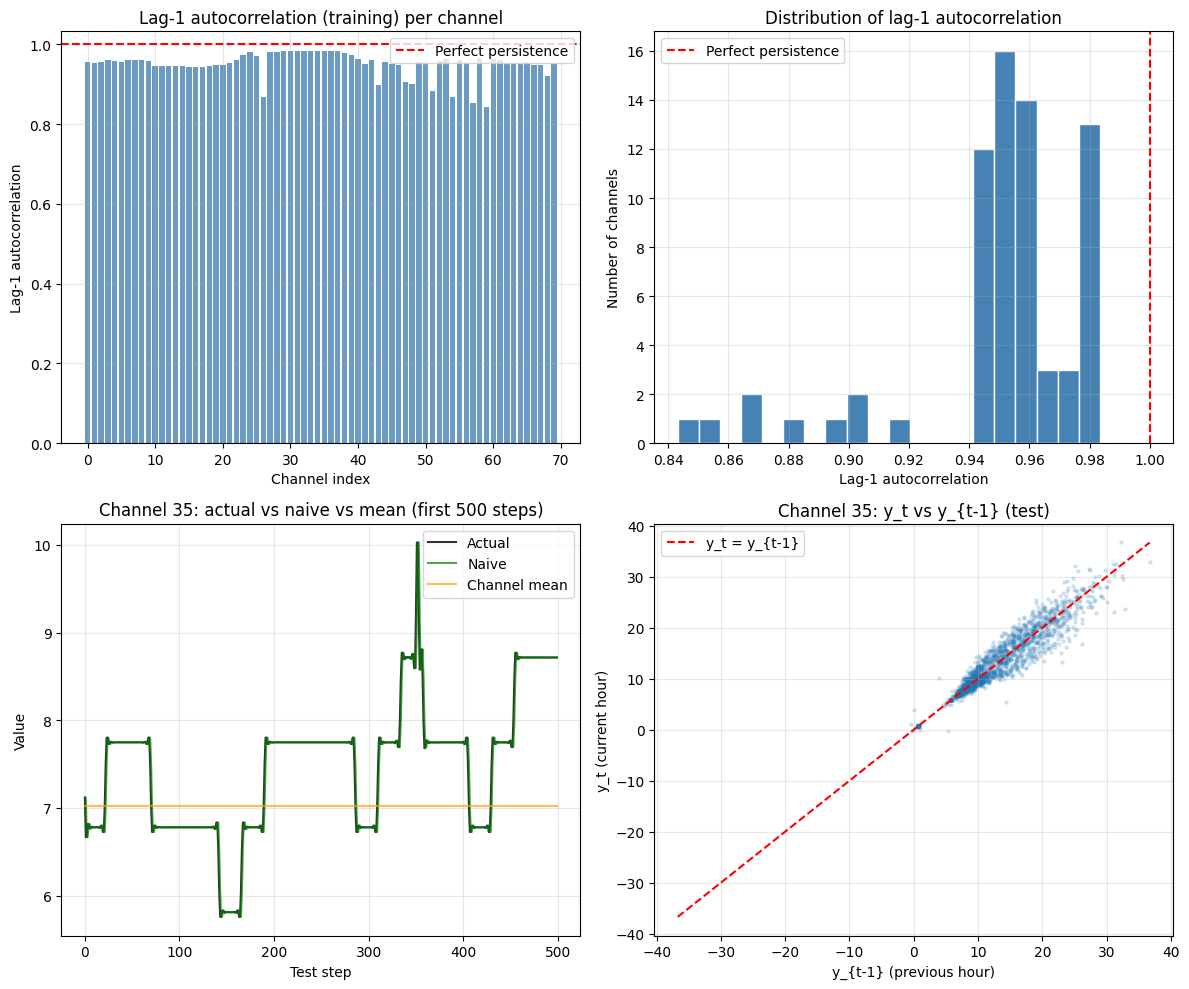

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1) Lag-1 autocorrelation per channel
ax1 = axes[0, 0]
ax1.bar(range(N), autocorr_lag1, color="steelblue", alpha=0.8)
ax1.axhline(1.0, color="red", linestyle="--", label="Perfect persistence")
ax1.set_xlabel("Channel index")
ax1.set_ylabel("Lag-1 autocorrelation")
ax1.set_title("Lag-1 autocorrelation (training) per channel")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2) Histogram of lag-1 autocorrelations
ax2 = axes[0, 1]
ax2.hist(autocorr_lag1, bins=20, color="steelblue", edgecolor="white")
ax2.axvline(1.0, color="red", linestyle="--", label="Perfect persistence")
ax2.set_xlabel("Lag-1 autocorrelation")
ax2.set_ylabel("Number of channels")
ax2.set_title("Distribution of lag-1 autocorrelation")
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3) One channel: actual vs naive vs channel-mean (first 500 test steps)
ch = N // 2
t_slice = slice(0, min(500, n_test))
ax3 = axes[1, 0]
ax3.plot(Z_test[t_slice, ch], label="Actual", color="black", alpha=0.8)
ax3.plot(pred_naive[t_slice, ch], label="Naive", color="green", alpha=0.7)
ax3.plot(pred_channel_mean[t_slice, ch], label="Channel mean", color="orange", alpha=0.7)
ax3.set_xlabel("Test step")
ax3.set_ylabel("Value")
ax3.set_title(f"Channel {ch}: actual vs naive vs mean (first {min(500, n_test)} steps)")
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4) y_t vs y_{t-1} scatter (one channel, test)
ax4 = axes[1, 1]
y_prev = Z_test[:-1, ch]
y_curr = Z_test[1:, ch]
ax4.scatter(y_prev, y_curr, alpha=0.15, s=5)
mx = max(np.max(np.abs(y_prev)), np.max(np.abs(y_curr)), 1e-6)
ax4.plot([-mx, mx], [-mx, mx], "r--", label="y_t = y_{t-1}")
ax4.set_xlabel("y_{t-1} (previous hour)")
ax4.set_ylabel("y_t (current hour)")
ax4.set_title(f"Channel {ch}: y_t vs y_{{t-1}} (test)")
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusion: is it a coincidence?

**No.** If the data show:
- **High lag-1 autocorrelation** (near 1) → the best linear prediction of \(y_t\) from \(y_{t-1}\) is almost \(y_{t-1}\).  
- **Small step size** relative to level → hour-to-hour changes are small, so repeating the last value gives small errors.  
- **Naive beats mean predictors** by a clear margin → the series are not just "constant"; they **track** the previous value.  

So the naive predictor wins because **your spectrum series are highly persistent at 1-hour resolution**: the next hour is very similar to the last hour. LSTMs and other models add capacity (and noise) without gaining much over this simple rule. To beat naive you may need longer-horizon prediction, different resolution, or features that capture *when* persistence breaks.